# IAU Projekt
## Fáza 1: Prieskumná analýza dát

**Predmet:** Inteligentná analýza údajov (IAU)<br>
**Akademický rok / semester:** 2026/2027<br>
**Cvičiaci:** Ing. Laura Krajčovičová<br>
**Číslo datasetu:** 038<br>
**Autori:** Adam Kavoň, Jakub Žúbor

## Úvod

Cieľom projektu je predikovať zlyhanie (premenná `failure`) jednotky na výrobu vzduchu vo vlakoch na základe senzorových dát. V tejto fáze vykonávame prieskumnú analýzu, identifikujeme problémy v dátach a štatisticky overujeme dve hypotézy.

## Riešenie

Na začiatok je potrebné si importovať všetky knižnice, ktoré budeme pri práci s dátami potrebovať.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1.1 A) Analýza štruktúr dát

Dáta sa skladajú z troch súborov:
- `gateways.csv` – informácie o bránach (gateway), ktoré zbierajú dáta (výrobca, firmvér, model, poloha, dátum inštalácie, ...)
- `readings.csv` – senzorové merania
- `units.csv` – informácie o jednotkách (APU)
  
Ako prvé si vypíšeme obsah dátových súborov, aby sme zistili ich štruktúru.

In [6]:
for name in ["units", "readings", "gateways"]:
    print(f"===== {name} =====")
    with open(f"data/{name}.csv", "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            print(i, repr(line))
            if i >= 4:
                break
    print()

===== units =====
0 'install_region,id_unit,owner_operator,last_overhaul,modelCode,dutyClass,depotId,hoursService,numberSerial\n'
1 'New Shane,1,Antunes,"10/03/2023, 00:00:00",APU-12,3,106,34094.60000,SG-1619-42643\n'
2 'Tomar,2,Wiek GmbH & Co. KG,"03/26/2020, 00:00:00",XC-7,1,111,,ZD-8362-37250\n'
3 'Gouveia,3,Wagner,"06/10/2019, 00:00:00",APU-15,normal,79,27642.50000,IG-0808-58786\n'
4 'Vila Nova de Foz Côa,4,Lima,2015-10-14,APU-12,1,104,3461.60000,OQ-3972-90589\n'

===== readings =====
0 'id_unit\tts_cycle\tmotor_current\tfilter_dp\toilTemperature\tpressure_reservoir\tpressureOil\trms_vibration\tflowmeter\thumidityIntake\tambientNoise\tdewpoint_discharge\taux_current\tFailure\n'
1 'U00890\t01/05/2023, 02:01:00\t6.03488\t12.35880\t52.66939\t8.61464\t3.95319\t4.28315\t31.04074\t86.68502\t64.70465\t7.37748\t2.07710\t0\n'
2 'U90104\t2023/01/07\t5.88784\t20.12438\t77.76356\t8.41482\t3.15135\t2.52806\t29.53863\t88.80272\t84.87385\t11.06149\t3.47304\t0\n'
3 'U01151\t28 Jan 2023\t0.61381\t3

Z výpisu vidíme, že každý súbor používa iný separátor (units "," , readings "\t" , gateways ";"). Súbory budeme otvárať s využitím príslušného operátora.

In [3]:
units_data = pd.read_csv("data/units.csv", sep=",")
units_data

,install_region,id_unit,owner_operator,last_overhaul,modelCode,dutyClass,depotId,hoursService,numberSerial
0,New Shane,1,Antunes,"10/03/2023, 00:00:00",APU-12,3,106,34094.6,SG-1619-42643
1,Tomar,2,Wiek GmbH & Co. KG,"03/26/2020, 00:00:00",XC-7,1,111,NaN,ZD-8362-37250
2,Gouveia,3,Wagner,"06/10/2019, 00:00:00",APU-15,normal,79,27642.5,IG-0808-58786
3,Vila Nova de Foz Côa,4,Lima,2015-10-14,APU-12,1,104,3461.6,OQ-3972-90589
4,Lippstadt,5,Gaspar Ferreira S.A.,"04/26/2023, 00:00:00",APU-12,1,18,4657.5,OL-0793-38153
...,...,...,...,...,...,...,...,...,...
1995,Winterston,1996,Leal S/A,18 Dec 2023,XC-7,3,33,NaN,HP-7622-05671
1996,Goslar,1997,Johnson-Sanchez,08 Feb 2017,APU-20,L,7,14979.5,FZ-9328-81090
1997,Vila Nova de Santo André,1998,Antunes,2016/05/03,APU-12,2,68,9928.8,BV-6559-48073
1998,Lippstadt,1999,Antunes,2024/09/20,APU-20,2,8,29535.8,NJ-5380-69337


In [4]:
units_data.info()
units_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   install_region  2000 non-null   str    
 1   id_unit         2000 non-null   int64  
 2   owner_operator  2000 non-null   str    
 3   last_overhaul   2000 non-null   str    
 4   modelCode       2000 non-null   str    
 5   dutyClass       2000 non-null   str    
 6   depotId         2000 non-null   int64  
 7   hoursService    1900 non-null   float64
 8   numberSerial    2000 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 140.8 KB


(2000, 9)

units.csv obsahuje 2000 riadkov a 9 stĺpcov. Vo výpise taktiež vidno 9 atribútov, ich dátový typ a počet nie Null záznamov. Atribút hoursService obsahuje ako jediný Null záznamy, konkrétne 100 takých záznamov.

In [7]:
readings_data = pd.read_csv("data/readings.csv", sep="\t")
readings_data

,id_unit,ts_cycle,motor_current,filter_dp,oilTemperature,pressure_reservoir,pressureOil,rms_vibration,flowmeter,humidityIntake,ambientNoise,dewpoint_discharge,aux_current,Failure
0,U00890,"01/05/2023, 02:01:00",6.03488,12.35880,52.66939,8.61464,3.95319,4.28315,31.04074,86.68502,64.70465,7.37748,2.07710,0
1,U90104,2023/01/07,5.88784,20.12438,77.76356,8.41482,3.15135,2.52806,29.53863,88.80272,84.87385,11.06149,3.47304,0
2,U01151,28 Jan 2023,0.61381,34.03841,41.90010,7.82918,2.98944,NaN,26.94321,40.04785,84.85633,7.64956,2.75321,1
3,U00870,02 Dec 2023,7.36066,30.62395,64.68951,8.79319,3.51568,1.12909,25.36901,78.50330,61.72889,8.17558,2.15853,0
4,U01371,2023-07-13,4.25880,40.91751,62.48404,8.82556,3.55145,4.25855,34.66068,33.28814,70.13243,5.51669,1.47229,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13934,U01374,06 Nov 2023,7.71051,NaN,64.36301,8.83308,3.95782,2.89603,28.43260,64.50666,78.69199,11.35168,1.73991,1
13935,U01891,2023-04-14,5.22230,12.13601,60.34316,9.78535,4.58946,2.27918,23.82831,29.91265,81.72715,11.50342,3.82224,0
13936,U00293,"03/11/2023, 19:52:00",3.40618,13.44212,61.52971,8.60193,3.01348,2.19284,26.14997,91.37227,76.51522,7.94773,4.15677,0
13937,U00167,2023-08-27,5.66443,42.84716,50.37179,8.02551,2.67634,5.28309,25.52513,66.75342,79.44340,7.43455,3.37710,1


In [7]:
readings_data.info()
readings_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 13939 entries, 0 to 13938
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_unit             13939 non-null  str    
 1   ts_cycle            13939 non-null  str    
 2   motor_current       13939 non-null  float64
 3   filter_dp           13369 non-null  float64
 4   oilTemperature      13939 non-null  float64
 5   pressure_reservoir  13939 non-null  float64
 6   pressureOil         13939 non-null  float64
 7   rms_vibration       13416 non-null  float64
 8   flowmeter           13939 non-null  float64
 9   humidityIntake      13209 non-null  float64
 10  ambientNoise        13939 non-null  float64
 11  dewpoint_discharge  13939 non-null  float64
 12  aux_current         13939 non-null  float64
 13  Failure             13939 non-null  int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 1.5 MB


(13939, 14)

units.csv obsahuje 13939 riadkov a 14 stĺpcov. Vo výpise taktiež vidno 14 atribútov, ich dátový typ a počet nie Null záznamov. Ani jeden atribút nemá Null záznam. Taktiež sa tu nachádza premenná `Failure`. Na modelovanie preto bude potrebné pripojiť atribúty z units a gateways k meraniam cez `id_unit`.

In [8]:
gateways_data = pd.read_csv("data/gateways.csv", sep=";")
gateways_data

,id_unit,macAddress,Ipv4,id_gateway,signal_dbm,dateInstall,lat,vendor,version_firmware,hardwareModel,depotId,technician,lon
0,1905.0,78:c7:eb:c0:ea:9b,145.254.205.111,GW-00000,-72.6,18 Jul 2018,40.69655,Johann GmbH,v2.7.0,GWX-200,97,Gonçalo do Lopes,-7.35887
1,467.0,ed:67:e9:95:b0:4c,85.40.9.139,GW-00001,-82.7,2020/11/16,39.00417,Wagner,v1.2.5,GWX-300,109,Evelyn Tintzmann,-7.52314
2,1884.0,14:82:e1:29:a9:85,25.95.112.105,GW-00002,-61.2,2019-09-14,38.66537,Metz GmbH & Co. KGaA,v3.4.1,GWX-300,35,Ângela Oliveira,-6.27268
3,325.0,6a:a1:1e:b7:67:0f,38.89.178.61,GW-00003,-78.1,19 Sep 2020,41.46158,Riehl Zahn GmbH & Co. OHG,v2.7.0,GWX-100,65,Audrey Levine,-8.73627
4,765.0,fc:c5:29:5f:f6:92,228.109.20.169,GW-00004,-58.4,"02/18/2023, 00:00:00",41.13818,Wähner,v3.4.1,GWX-100,4,Dr. Rosmarie Beier,-6.68186
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,NaN,fe:41:b4:d4:28:de,185.89.83.228,GW-15995,-64.7,2017/02/01,41.66279,Cameron-Smith,v2.7.0,NODE-9,5,Tiago Miranda,-7.05795
15996,NaN,4f:57:17:1d:57:e9,111.44.166.49,GW-15996,-59.9,2016/12/08,39.70297,"Pierce, Fuller and Lester",v1.2.5,GWX-300,73,Erika Cox,-7.37284
15997,NaN,30:e8:13:74:e9:51,239.119.60.122,GW-15997,-73.9,25 Nov 2022,38.78948,Lozano-Nguyen,v2.7.0,NODE-9,97,Catarina Lima,-7.70229
15998,NaN,6d:37:25:3e:c9:6c,127.190.201.48,GW-15998,-80.1,2021-03-28,38.76347,Möchlichen,v3.4.1,GWX-300,40,Gonçalo do Lopes,-7.04316


In [9]:
gateways_data.info()
gateways_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_unit           2000 non-null   float64
 1   macAddress        16000 non-null  str    
 2   Ipv4              16000 non-null  str    
 3   id_gateway        16000 non-null  str    
 4   signal_dbm        16000 non-null  float64
 5   dateInstall       16000 non-null  str    
 6   lat               16000 non-null  float64
 7   vendor            16000 non-null  str    
 8   version_firmware  16000 non-null  str    
 9   hardwareModel     16000 non-null  str    
 10  depotId           16000 non-null  int64  
 11  technician        16000 non-null  str    
 12  lon               16000 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.6 MB


(16000, 13)

units.csv obsahuje 16000 riadkov a 13 stĺpcov. Vo výpise taktiež vidno 13 atribútov, ich dátový typ a počet nie Null záznamov. Atribút id_unit obsahuje 14000 Null hodnôt.

## 1.1 B) Analýza jednotlivých atribútov

Na analyzovanie použijeme všetkých 11 meraných hodnôt (atribútov) zo súboru readings.csv.

In [10]:
sensor_cols = ["motor_current", "filter_dp", "oilTemperature", "pressure_reservoir",
               "pressureOil", "rms_vibration", "flowmeter", "humidityIntake",
               "ambientNoise", "dewpoint_discharge", "aux_current"]

Vypíšeme si ich základné parametre a grafy

In [11]:
readings_data[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
motor_current,13939.0,5.206951,3.198468,0.00000,3.698135,4.998400,6.496515,99.00000
filter_dp,13369.0,23.898041,11.194712,6.86921,16.207310,21.268820,28.608820,120.00000
oilTemperature,13939.0,52.211767,54.039790,-999.00000,47.005100,54.729480,62.781165,95.00000
pressure_reservoir,13939.0,8.706751,0.599462,6.57154,8.301630,8.711130,9.117900,10.50000
pressureOil,13939.0,3.704381,0.569443,1.50000,3.321390,3.697560,4.083895,5.94478
rms_vibration,13416.0,3.086164,1.638037,0.50000,1.931115,2.712025,3.843480,14.00000
flowmeter,13939.0,27.968704,3.977421,15.00000,25.311430,27.969780,30.640005,40.00000
humidityIntake,13209.0,52.446937,24.510092,10.00095,31.264280,52.411390,73.450010,94.99993
ambientNoise,13939.0,74.968808,6.069568,55.00000,70.846530,74.989370,79.066095,95.00000
dewpoint_discharge,13939.0,8.009490,3.523204,-6.30084,5.642425,7.957440,10.429030,23.57147


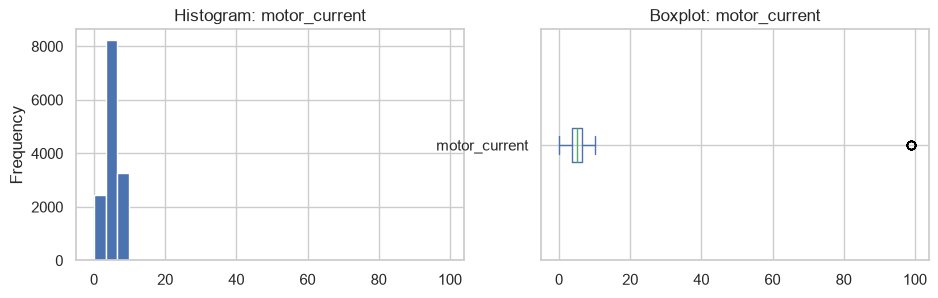

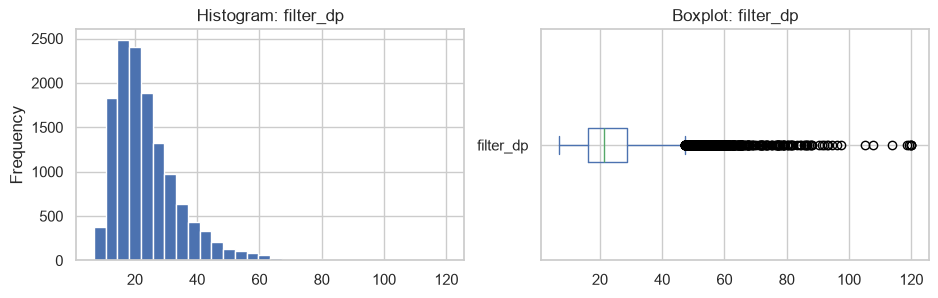

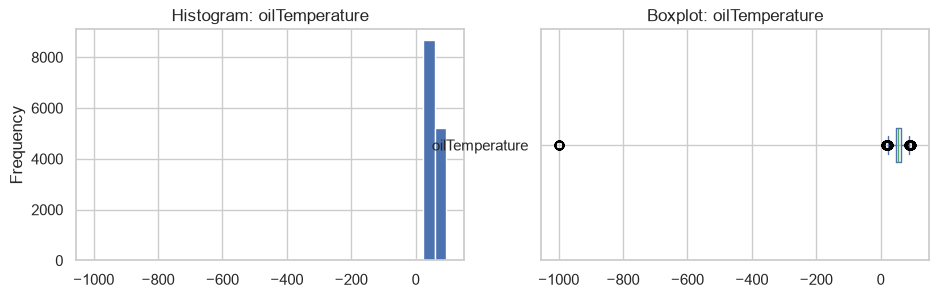

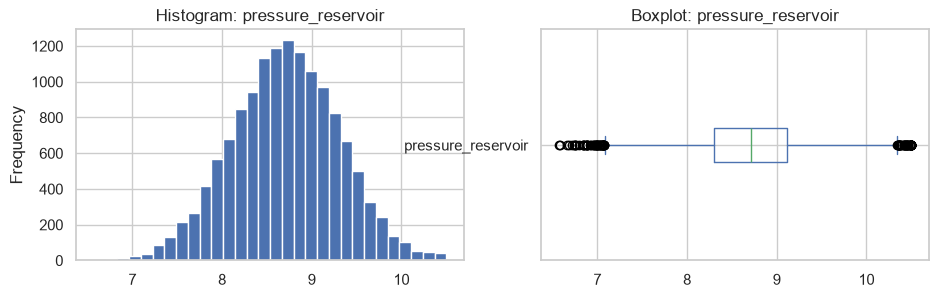

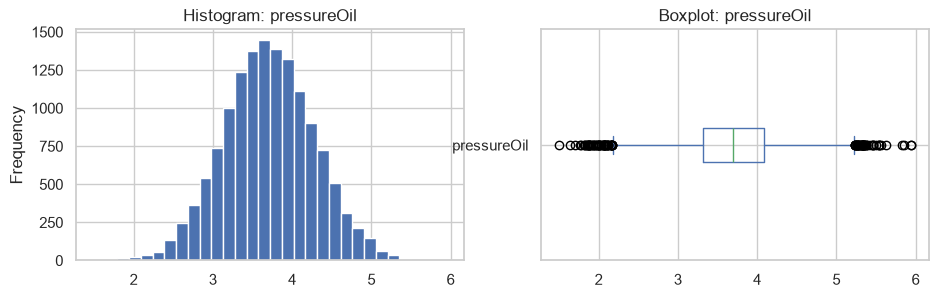

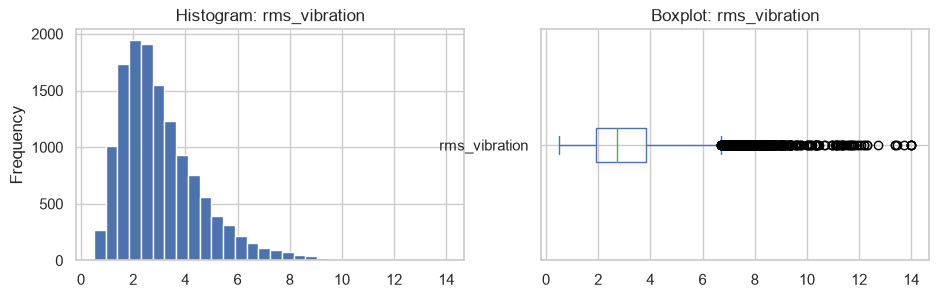

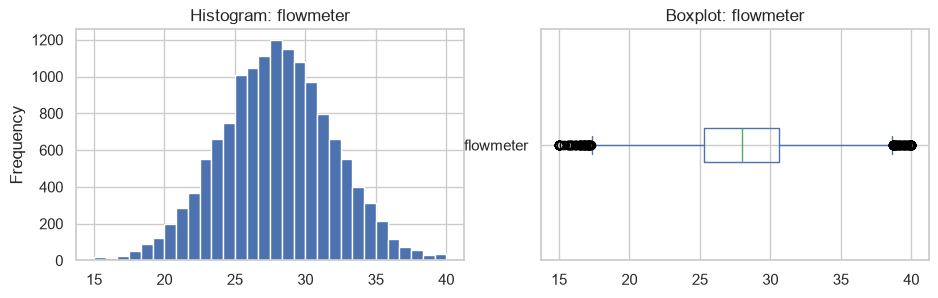

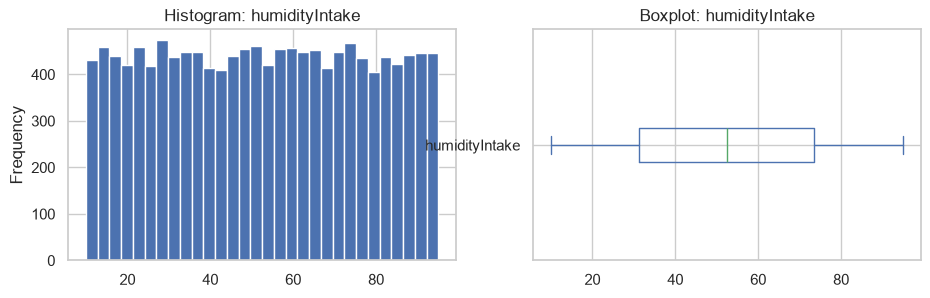

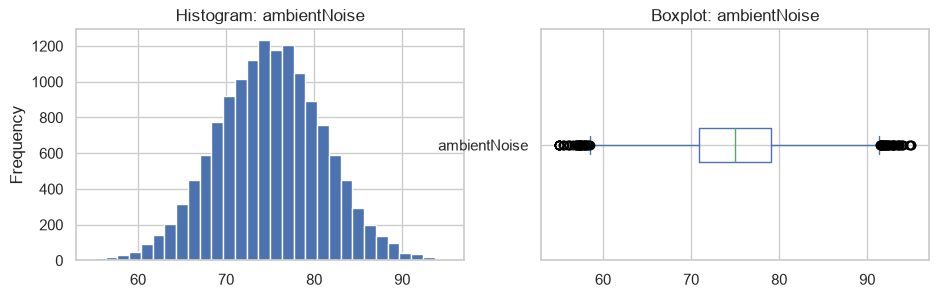

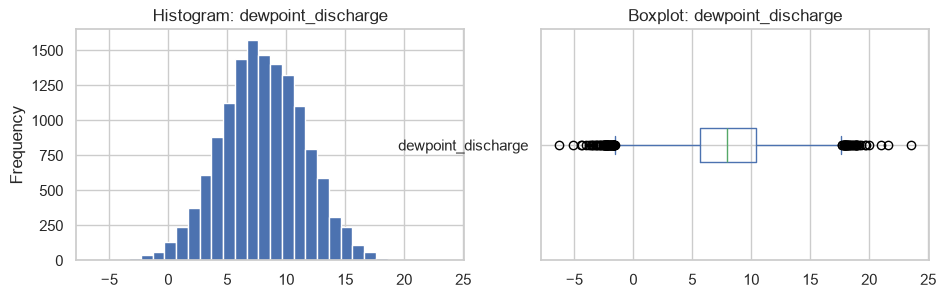

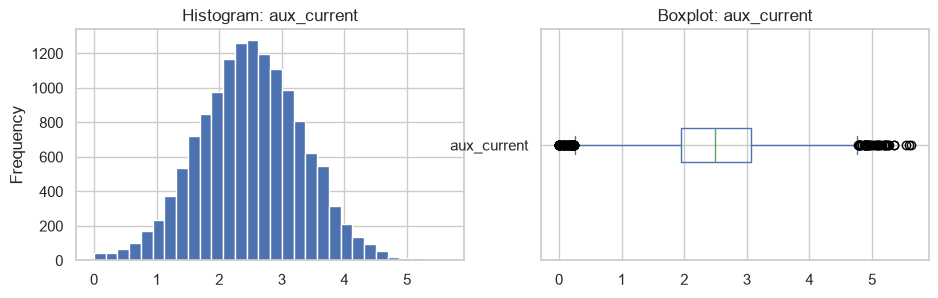

In [16]:
for sen in sensor_cols:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3))
    readings_data[sen].plot.hist(bins=30, ax=ax[0], title=f"Histogram: {sen}")
    readings_data[sen].plot.box(vert=False, ax=ax[1], title=f"Boxplot: {sen}")
    plt.show()

**1. `motor_current`**  
Väčšina hodnôt je v rozsahu 0–10 (medián 5,0, priemer 5,2, std 3,2). Maximum 99 je ďaleko od zvyšku dát, pravdepodobne chyba merania alebo zástupná hodnota. Rozdelenie je inak zhruba symetrické.

**2. `filter_dp`**  
Medián 21,3 je nižší ako priemer 23,9 a maximum 120 je ďaleko od Q3 (28,6), takže rozdelenie je pravostranne zošikmené s odľahlými hodnotami. Chýba 570 hodnôt.

**3. `oilTemperature`**  
Minimum -999 je fyzikálne nemožná teplota, ide o zástupnú hodnotu za chýbajúce meranie. Skresľuje priemer (52,2) aj smerodajnú odchýlku (54,0). Bežné hodnoty sú podľa mediánu okolo 50–60, maximum je 95.

**4. `pressure_reservoir`**  
Rozsah 6,6–10,5, priemer 8,7 sa takmer rovná mediánu 8,7, malý rozptyl (std 0,6). Rozdelenie je symetrické, bez zjavných problémov.

**5. `pressureOil`**  
Rozsah 1,5–5,9, priemer 3,7 sa takmer rovná mediánu 3,7, malý rozptyl (std 0,6). Hodnoty sú v rozumnom rozsahu, bez zjavných problémov.

**6. `rms_vibration`**  
Medián 2,7 je nižší ako priemer 3,1 a maximum 14 je výrazne vyššie, rozdelenie je pravostranne zošikmené s odľahlými hodnotami. Chýba 523 hodnôt.

**7. `flowmeter`**  
Rozsah 15–40, priemer 28,0 sa rovná mediánu 28,0 (std 4,0). Rozdelenie je symetrické, hodnoty sú v rozumnom rozsahu.

**8. `humidityIntake`**  
Rozsah 10–95 % spĺňa očakávaný rozsah 0–100 %. Chýba 730 hodnôt, najviac zo všetkých senzorov.

**9. `ambientNoise`**  
Rozsah 55–95, priemer 75,0 sa rovná mediánu 75,0 (std 6,1). Rozdelenie je symetrické, bez zjavných problémov.

**10. `dewpoint_discharge`**  
Rozsah -6,3 až 23,6, priemer 8,0 sa rovná mediánu 8,0 (std 3,5). Záporné hodnoty sú pri rosnom bode fyzikálne možné, takže sú v poriadku.

**Súhrn:** Problémové hodnoty (-999 v `oilTemperature`, 99 v `motor_current`, extrémy vo `filter_dp` a `rms_vibration`) a chýbajúce hodnoty (`humidityIntake`, `filter_dp`, `rms_vibration`).

## 1.1 C) Párová analýza dát: vzťahy a závislostí medzi dvojicami atribútov

In [ ]:
...

## 1.1 D) Párová analýza dát: závislosti medzi predikovanou premennou a ostatnými premennými

In [9]:
...

Ellipsis

## 1.1 E) Dokumentácia

In [10]:
...

Ellipsis

## 1.2 A) Identifikácia problémov v dátach

Ako prvé skontrolujeme duplicitné záznamy

In [11]:
print(units_data.duplicated().sum())
print(readings_data.duplicated().sum())
print(gateways_data.duplicated().sum())

0
206
0


### Úprava datasetu units
Najprv zjednotíme formát dátumov

In [12]:
units_data['last_overhaul'] = pd.to_datetime(units_data['last_overhaul'], format='mixed', errors='coerce')

Následne zjednotíme formát v stĺpci 'dutyClass' pomocou mapovania hodnôt

In [13]:
units_data['dutyClass'] = units_data['dutyClass'].astype(str).str.strip()

duty_class_map = {
    # Light (Trida 1)
    '1': 'light',
    'L': 'light',
    'light': 'light',
    
    # Medium (Trida 2 / Normal)
    '2': 'medium',
    'N': 'medium',
    'normal': 'medium',
    'med': 'medium',
    
    # Heavy (Trida 3)
    '3': 'heavy',
    'H': 'heavy',
    'heavy': 'heavy'
}

units_data['dutyClass'] = units_data['dutyClass'].map(duty_class_map)
units_data

,install_region,id_unit,owner_operator,last_overhaul,modelCode,dutyClass,depotId,hoursService,numberSerial
0,New Shane,1,Antunes,2023-10-03,APU-12,heavy,106,34094.6,SG-1619-42643
1,Tomar,2,Wiek GmbH & Co. KG,2020-03-26,XC-7,light,111,NaN,ZD-8362-37250
2,Gouveia,3,Wagner,2019-06-10,APU-15,medium,79,27642.5,IG-0808-58786
3,Vila Nova de Foz Côa,4,Lima,2015-10-14,APU-12,light,104,3461.6,OQ-3972-90589
4,Lippstadt,5,Gaspar Ferreira S.A.,2023-04-26,APU-12,light,18,4657.5,OL-0793-38153
...,...,...,...,...,...,...,...,...,...
1995,Winterston,1996,Leal S/A,2023-12-18,XC-7,heavy,33,NaN,HP-7622-05671
1996,Goslar,1997,Johnson-Sanchez,2017-02-08,APU-20,light,7,14979.5,FZ-9328-81090
1997,Vila Nova de Santo André,1998,Antunes,2016-05-03,APU-12,medium,68,9928.8,BV-6559-48073
1998,Lippstadt,1999,Antunes,2024-09-20,APU-20,medium,8,29535.8,NJ-5380-69337


### Úprava datasetu readings

Odstránime duplicitné záznamy

In [14]:
readings_data = readings_data.drop_duplicates()

Zjednotíme formáty dátumov a id_unit

In [15]:
readings_data['ts_cycle'] = pd.to_datetime(readings_data['ts_cycle'], format='mixed', errors='coerce')

readings_data['id_unit'] = (readings_data['id_unit'].astype(str).str.extract(r'(\d+)')[0].astype('Int64'))
readings_data

,id_unit,ts_cycle,motor_current,filter_dp,oilTemperature,pressure_reservoir,pressureOil,rms_vibration,flowmeter,humidityIntake,ambientNoise,dewpoint_discharge,aux_current,Failure
0,890,2023-01-05 02:01:00,6.03488,12.35880,52.66939,8.61464,3.95319,4.28315,31.04074,86.68502,64.70465,7.37748,2.07710,0
1,90104,2023-01-07 00:00:00,5.88784,20.12438,77.76356,8.41482,3.15135,2.52806,29.53863,88.80272,84.87385,11.06149,3.47304,0
2,1151,2023-01-28 00:00:00,0.61381,34.03841,41.90010,7.82918,2.98944,NaN,26.94321,40.04785,84.85633,7.64956,2.75321,1
3,870,2023-12-02 00:00:00,7.36066,30.62395,64.68951,8.79319,3.51568,1.12909,25.36901,78.50330,61.72889,8.17558,2.15853,0
4,1371,2023-07-13 00:00:00,4.25880,40.91751,62.48404,8.82556,3.55145,4.25855,34.66068,33.28814,70.13243,5.51669,1.47229,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13728,787,2023-04-07 00:00:00,5.48908,23.27476,51.77167,8.46053,3.37965,1.80045,34.12157,73.31670,77.35551,10.24995,2.37349,0
13729,377,2023-09-09 00:00:00,4.28824,12.26344,53.33091,9.91977,4.82201,6.20552,27.86084,NaN,79.43856,10.96477,1.04483,0
13730,529,2023-06-10 00:00:00,1.41276,15.10896,47.44194,8.54089,3.46452,2.26122,19.57754,37.97271,72.33752,7.29306,2.88341,0
13731,1106,2023-01-23 00:00:00,4.84301,38.20607,57.95232,8.78364,3.64470,3.62674,30.64132,66.25691,71.36083,5.78626,0.21427,0


### Úprava datasetu gateways
Zjednotíme formáty dátumov a id_unit

In [16]:
gateways_data['dateInstall'] = pd.to_datetime(gateways_data['dateInstall'], format='mixed', errors='coerce')
gateways_data['id_unit'] = (gateways_data['id_unit'].astype(str).str.extract(r'(\d+)')[0].astype('Int64'))
gateways_data

,id_unit,macAddress,Ipv4,id_gateway,signal_dbm,dateInstall,lat,vendor,version_firmware,hardwareModel,depotId,technician,lon
0,1905,78:c7:eb:c0:ea:9b,145.254.205.111,GW-00000,-72.6,2018-07-18,40.69655,Johann GmbH,v2.7.0,GWX-200,97,Gonçalo do Lopes,-7.35887
1,467,ed:67:e9:95:b0:4c,85.40.9.139,GW-00001,-82.7,2020-11-16,39.00417,Wagner,v1.2.5,GWX-300,109,Evelyn Tintzmann,-7.52314
2,1884,14:82:e1:29:a9:85,25.95.112.105,GW-00002,-61.2,2019-09-14,38.66537,Metz GmbH & Co. KGaA,v3.4.1,GWX-300,35,Ângela Oliveira,-6.27268
3,325,6a:a1:1e:b7:67:0f,38.89.178.61,GW-00003,-78.1,2020-09-19,41.46158,Riehl Zahn GmbH & Co. OHG,v2.7.0,GWX-100,65,Audrey Levine,-8.73627
4,765,fc:c5:29:5f:f6:92,228.109.20.169,GW-00004,-58.4,2023-02-18,41.13818,Wähner,v3.4.1,GWX-100,4,Dr. Rosmarie Beier,-6.68186
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,<NA>,fe:41:b4:d4:28:de,185.89.83.228,GW-15995,-64.7,2017-02-01,41.66279,Cameron-Smith,v2.7.0,NODE-9,5,Tiago Miranda,-7.05795
15996,<NA>,4f:57:17:1d:57:e9,111.44.166.49,GW-15996,-59.9,2016-12-08,39.70297,"Pierce, Fuller and Lester",v1.2.5,GWX-300,73,Erika Cox,-7.37284
15997,<NA>,30:e8:13:74:e9:51,239.119.60.122,GW-15997,-73.9,2022-11-25,38.78948,Lozano-Nguyen,v2.7.0,NODE-9,97,Catarina Lima,-7.70229
15998,<NA>,6d:37:25:3e:c9:6c,127.190.201.48,GW-15998,-80.1,2021-03-28,38.76347,Möchlichen,v3.4.1,GWX-300,40,Gonçalo do Lopes,-7.04316
